## 42. Trapping Rain Water

Given n non-negative integers representing an elevation map where the width of each bar is 1, compute how much water it can trap after raining.

 
Example 1:

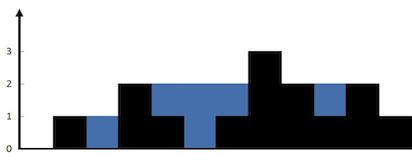

Input: height = [0,1,0,2,1,0,1,3,2,1,2,1]
Output: 6
Explanation: The above elevation map (black section) is represented by array [0,1,0,2,1,0,1,3,2,1,2,1]. In this case, 6 units of rain water (blue section) are being trapped.
Example 2:

Input: height = [4,2,0,3,2,5]
Output: 9
 

Constraints:

n == height.length
1 <= n <= 2 * 104
0 <= height[i] <= 105

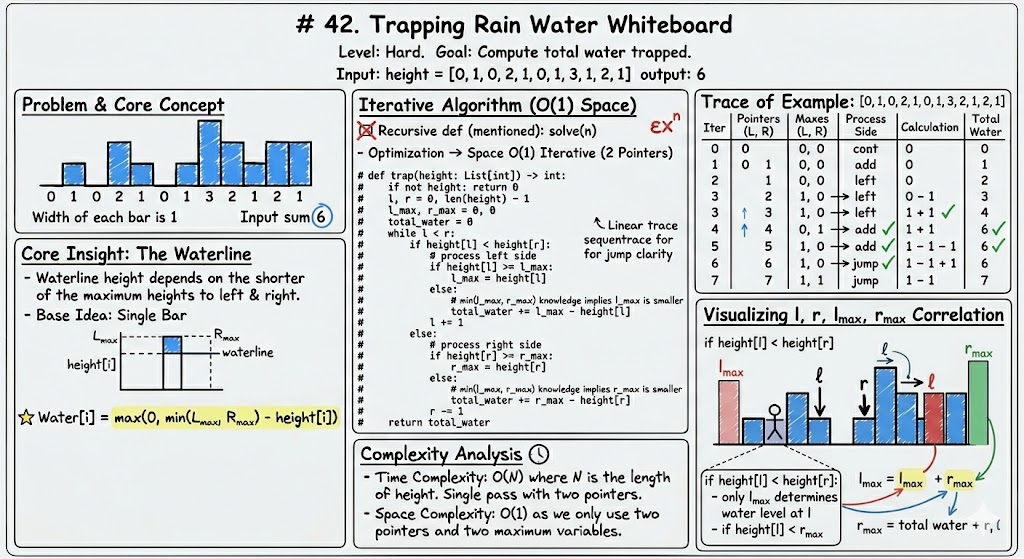

In [ ]:

class Solution:
    def trap(self, height: list[int]) -> int:
       # Edge Case: Se não houver barras suficientes para formar um vale
       if not height or len(height) < 3:
           return 0

       # Inicialização dos "circuitos" (ponteiros e picos)
       left, right = 0, len(height) - 1
       left_max, right_max = 0, 0
       total = 0

       # O Flow: Os ponteiros se movem um em direção ao outro
       while left < right:
           # O lado menor é sempre o nosso limitante (o gargalo)
           if height[left] < height[right]:
               # Se a altura atual for um novo pico, atualizamos o "muro"
               if height[left] >= left_max:
                   left_max = height[left]
               # Caso contrário, estamos em um vale e calculamos a "cheia"
               else:
                   total += left_max - height[left]
               left += 1
           else:
               # Lógica espelhada para o lado direito
               if height[right] >= right_max:
                   right_max = height[right]
               else:
                   total += right_max - height[right]
               right -= 1

       return total



In [ ]:

class Solution:
    def trap(self, height: list[int]) -> int:
       # Edge Case: Se não houver barras suficientes para formar um vale
       if not height or len(height) < 3:
           return 0

       # Inicialização dos "circuitos" (ponteiros e picos)
       left, right = 0, len(height) - 1
       left_max, right_max = 0, 0
       total = 0

       # O Flow: Os ponteiros se movem um em direção ao outro
       while left < right:
           # O lado menor é sempre o nosso limitante (o gargalo)
           if height[left] < height[right]:
               # Se a altura atual for um novo pico, atualizamos o "muro"
               if height[left] >= left_max:
                   left_max = height[left]
               # Caso contrário, estamos em um vale e calculamos a "cheia"
               else:
                   total += left_max - height[left]
               left += 1
           else:
               # Lógica espelhada para o lado direito
               if height[right] >= right_max:
                   right_max = height[right]
               else:
                   total += right_max - height[right]
               right -= 1

       return total




In [ ]:
class Solution:
    def trap_dp(self, height: list[int]) -> int:
        """
        DP Approach: Pre-compute max heights to the left and right of each position
        Time: O(n), Space: O(n)
        """
        if not height or len(height) < 3:
            return 0
        
        n = len(height)
        
        # max_left[i] = máxima altura à esquerda (incluindo posição i)
        max_left = [0] * n
        max_left[0] = height[0]
        for i in range(1, n):
            max_left[i] = max(max_left[i-1], height[i])
        
        # max_right[i] = máxima altura à direita (incluindo posição i)
        max_right = [0] * n
        max_right[n-1] = height[n-1]
        for i in range(n-2, -1, -1):
            max_right[i] = max(max_right[i+1], height[i])
        
        # Calcular água capturada em cada posição
        total = 0
        for i in range(n):
            # A água capturada é limitada pelo mínimo entre max_left e max_right
            water_level = min(max_left[i], max_right[i])
            total += max(0, water_level - height[i])
        
        return total


# Test Cases
sol = Solution()

# Test 1: [0,1,0,2,1,0,1,3,2,1,2,1] -> 6
test1 = [0,1,0,2,1,0,1,3,2,1,2,1]
assert sol.trap_dp(test1) == 6, f"Test 1 failed: got {sol.trap_dp(test1)}"

# Test 2: [4,2,0,3,2,5] -> 9
test2 = [4,2,0,3,2,5]
assert sol.trap_dp(test2) == 9, f"Test 2 failed: got {sol.trap_dp(test2)}"

# Test 3: Edge case - no water
test3 = [1,2,3,4,5]
assert sol.trap_dp(test3) == 0, f"Test 3 failed: got {sol.trap_dp(test3)}"

# Test 4: Edge case - all same height
test4 = [2,2,2,2]
assert sol.trap_dp(test4) == 0, f"Test 4 failed: got {sol.trap_dp(test4)}"

print("✓ All DP tests passed!")

✓ All DP tests passed!
